In [1]:
import pickle
import torch
import evaluate
import os
import csv

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from torch import nn
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset
from huggingface_hub import login
from transformers import AutoImageProcessor, ViTForImageClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from dotenv import load_dotenv

In [ ]:
### Login for Hugging Face model
load_dotenv()
login(token=os.environ["HF_TOKEN"])

### Setam seedul pt random
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

### Variabile globale
MODEL_NAME = "google/vit-large-patch16-224"
SPOSE_PATH = "spose_embedding_49d_sorted.txt"
IMAGE_SIZE = 224
EVAL_RESIZE = 256 

### VIT processor + move device to cuda
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME, use_fast = True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Augmentare inspirata din cum augumenteaza lucrarea datele pentru CUB
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
])

eval_transform = transforms.Compose([
    transforms.Resize(EVAL_RESIZE, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
])

### Dataset pentru x -> c -> y
class ConceptDataset(Dataset):
    def __init__(self, images_paths, labels_49d, labels, aug=None):
        self.images_paths = images_paths
        self.concepts = labels_49d
        self.labels = labels
        self.aug = aug

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, idx):
        img = Image.open(self.images_paths[idx]).convert("RGB")
        
        if self.aug is not None:
            img = self.aug(img)
            
        inputs = image_processor(
            images=img, 
            return_tensors="pt",
            do_resize=False,
            do_center_crop=False
        )
        
        pixel_values = inputs["pixel_values"].squeeze(0)
        concepts = torch.tensor(self.concepts[idx], dtype=torch.float32)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return {
            "pixel_values": pixel_values, 
            "concept_labels": concepts, 
            "labels": label_tensor
        }
        
### Metricile pe care le va urmarii modelul
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric   = evaluate.load("recall")

def compute_metrics(eval_pred):
    preds = eval_pred.predictions
    labels = eval_pred.label_ids
    
    logits = preds[0] if isinstance(preds, (tuple, list)) else preds
    true_labels = labels[0] if isinstance(labels, (tuple, list)) else labels
    
    predictions = np.argmax(logits, axis=-1)
    
    return {
        "accuracy":  accuracy_metric.compute(predictions=predictions, references=true_labels)["accuracy"],
        "f1":        f1_metric.compute(predictions=predictions, references=true_labels, average="macro")["f1"],
        "precision": precision_metric.compute(predictions=predictions, references=true_labels, average="macro")["precision"],
        "recall":    recall_metric.compute(predictions=predictions, references=true_labels, average="macro")["recall"],
    }


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
class JointBottleneckViT(nn.Module):
    def __init__(self, vit_path, num_concepts, num_classes, lambda_weight=1.0, **kwargs):
        super().__init__()
        self.vit = ViTForImageClassification.from_pretrained(vit_path, **kwargs)
        self.classifier = nn.Linear(num_concepts, num_classes)
        
        # Salvam lambda si loss-ul pentru a calcula mai incolo Loss-ul usor
        self.lambda_weight = lambda_weight
        self.task_loss_fct = nn.CrossEntropyLoss()
        self.concept_loss_fct = nn.MSELoss()

    def forward(self, pixel_values, labels=None, concept_labels=None):
        # Extragem conceptele adica x->c
        vit_outputs = self.vit(pixel_values=pixel_values)
        pred_concepts = vit_outputs.logits
        
        # Aplicam prezicerea finala c->y
        logits = self.classifier(pred_concepts)
        
        # Initializam dictionarul de output
        output = {"logits": logits, "pred_concepts": pred_concepts}
        
        # Calculam Joint Loss-ul
        if labels is not None and concept_labels is not None:
            task_loss = self.task_loss_fct(logits, labels)
            concept_loss = self.concept_loss_fct(pred_concepts, concept_labels)
            
            loss = task_loss + self.lambda_weight * concept_loss
            
            output["loss"] = loss 
            
        return output

In [ ]:
### Load images + labels parsing
with open("all_images.pkl", "rb") as f:
    imgs_path = pickle.load(f)
    
spose_mat = np.loadtxt(SPOSE_PATH)

label_names = {name: i for i, name in enumerate(list(imgs_path.keys()))}
all_data = []
all_labels = []
all_concepts = []

for s in imgs_path:
    np.random.shuffle(imgs_path[s])

    label = label_names[s]
    con = spose_mat[label]

    for img_path in imgs_path[s]:
        all_data.append(img_path)
        all_labels.append(label)
        all_concepts.append(con)

print(len(all_data), len(all_labels), len(all_concepts))

# 80% din date pentru train si 20% pt test
aux_data, test_data, aux_labels, test_labels, aux_concepts, test_concepts = train_test_split(
    all_data, all_labels, all_concepts,
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels
)

# Alegem 20% din datele de train pentru evaluare
train_data, eval_data, train_labels, eval_labels, train_concepts, eval_concepts = train_test_split(
    aux_data, aux_labels, aux_concepts,
    test_size=0.20,
    random_state=SEED,
    stratify=aux_labels
)

train_dataset = ConceptDataset(train_data, train_concepts, train_labels, train_transform)
eval_dataset = ConceptDataset(eval_data, eval_concepts, eval_labels, eval_transform)
test_dataset = ConceptDataset(test_data, test_concepts, test_labels, eval_transform)

26107 26107 26107


In [ ]:

### Modelul x -> c
model = JointBottleneckViT(
    vit_path="./vit_feature_prediction/run1/models", 
    num_concepts=49, 
    num_classes=len(imgs_path.keys()),
    lambda_weight=0.01,
    ignore_mismatched_sizes=True
)
model = model.to(device)

run_idx = 1
while os.path.exists(f"./vit_joint/run{run_idx}"):
    run_idx += 1
run_dir        = f"./vit_joint/run{run_idx}"
checkpoint_dir = os.path.join(run_dir, "checkpoints")
model_dir      = os.path.join(run_dir, "models")

os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(model_dir,      exist_ok=True)

args = TrainingArguments(
    output_dir=checkpoint_dir,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=30,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model ="f1",
    greater_is_better = True,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
)


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [6]:
train_output = trainer.train()
trainer.save_model(model_dir)

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,7.409901,7.052497,0.046924,0.029285,0.029189,0.040426
2,5.815518,4.922068,0.665549,0.599081,0.618466,0.648490
3,3.106295,2.262939,0.887240,0.868681,0.891898,0.881751
4,0.876539,0.889403,0.932009,0.925048,0.945173,0.929917
5,0.300711,0.602962,0.944937,0.938766,0.956001,0.943123
6,0.186014,0.536892,0.949725,0.944235,0.959517,0.948382
7,0.155198,0.498000,0.949485,0.944696,0.961845,0.947932
8,0.144283,0.460450,0.953316,0.948096,0.964257,0.951079
9,0.146620,0.509927,0.950203,0.945408,0.960287,0.949506
10,0.146249,0.453479,0.955949,0.950886,0.965642,0.954450


c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [7]:
trainer.callback_handler.callbacks = [
    cb for cb in trainer.callback_handler.callbacks 
    if cb.__class__.__name__ in ["ProgressCallback", "DefaultFlowCallback", "PrinterCallback"]
]


test_results = trainer.evaluate(test_dataset)

print("\nTest Results:")
print(f"Accuracy:  {test_results['eval_accuracy']:.4f}")
print(f"F1:        {test_results['eval_f1']:.4f}")
print(f"Precision: {test_results['eval_precision']:.4f}")
print(f"Recall:    {test_results['eval_recall']:.4f}")
print(f"Loss:      {test_results['eval_loss']:.4f}")

test_results_path = os.path.join(run_dir, "test_results.txt")
with open(test_results_path, "w") as f:
    f.write(f"Test Results:\n")
    f.write(f"Accuracy:  {test_results['eval_accuracy']:.4f}\n")
    f.write(f"F1:        {test_results['eval_f1']:.4f}\n")
    f.write(f"Precision: {test_results['eval_precision']:.4f}\n")
    f.write(f"Recall:    {test_results['eval_recall']:.4f}\n")
    f.write(f"Loss:      {test_results['eval_loss']:.4f}\n")

print(f"\nTest results saved to: {test_results_path}")


Test Results:
Accuracy:  0.9579
F1:        0.9545
Precision: 0.9670
Recall:    0.9562
Loss:      0.3926

Test results saved to: ./vit_joint/run2\test_results.txt


c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [8]:
print(trainer.state.log_history)
eval_history = [entry for entry in trainer.state.log_history]
print(eval_history)

[{'loss': 7.5330146484375, 'grad_norm': 0.932504415512085, 'learning_rate': 3.1834130781499207e-06, 'epoch': 0.47869794159885115, 'step': 500}, {'loss': 7.4099013671875, 'grad_norm': 3.756012201309204, 'learning_rate': 6.373205741626795e-06, 'epoch': 0.9573958831977023, 'step': 1000}, {'eval_loss': 7.052496910095215, 'eval_accuracy': 0.046923629399090255, 'eval_f1': 0.02928548222521163, 'eval_precision': 0.029189492510024784, 'eval_recall': 0.04042610571736785, 'eval_runtime': 82.6234, 'eval_samples_per_second': 50.555, 'eval_steps_per_second': 6.33, 'epoch': 1.0, 'step': 1045}, {'loss': 6.7104833984375, 'grad_norm': 6.576674938201904, 'learning_rate': 9.562998405103669e-06, 'epoch': 1.4356151268549544, 'step': 1500}, {'loss': 5.815517578125, 'grad_norm': 6.093503475189209, 'learning_rate': 1.2752791068580544e-05, 'epoch': 1.9143130684538057, 'step': 2000}, {'eval_loss': 4.922067642211914, 'eval_accuracy': 0.6655494373952597, 'eval_f1': 0.5990807626684871, 'eval_precision': 0.618465779

In [9]:
eval_history = [entry for entry in trainer.state.log_history if "eval_loss" in entry]

csv_path = os.path.join(checkpoint_dir, "result.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "loss", "accuracy", "f1", "precision", "recall"])
    writer.writeheader()
    for entry in eval_history:
        writer.writerow({
            "epoch": entry["epoch"],
            "loss": entry["eval_loss"],
            "accuracy": entry["eval_accuracy"],
            "f1": entry["eval_f1"],
            "precision": entry["eval_precision"],
            "recall": entry["eval_recall"],
        })
print(f"Metrics saved to {csv_path}")

data = {
    "epoch": [],
    "loss": [],
    "accuracy": [],
    "f1": [],
    "precision": [],
    "recall": [],
}

with open(csv_path, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        data["epoch"].append(float(row["epoch"]))
        data["loss"].append(float(row["loss"]))
        data["accuracy"].append(float(row["accuracy"]) if row["accuracy"] != "" else np.nan)
        data["f1"].append(float(row["f1"]) if row["f1"] != "" else np.nan)
        data["precision"].append(float(row["precision"]) if row["precision"] != "" else np.nan)
        data["recall"].append(float(row["recall"]) if row["recall"] != "" else np.nan)

Metrics saved to ./vit_joint/run2\checkpoints\result.csv


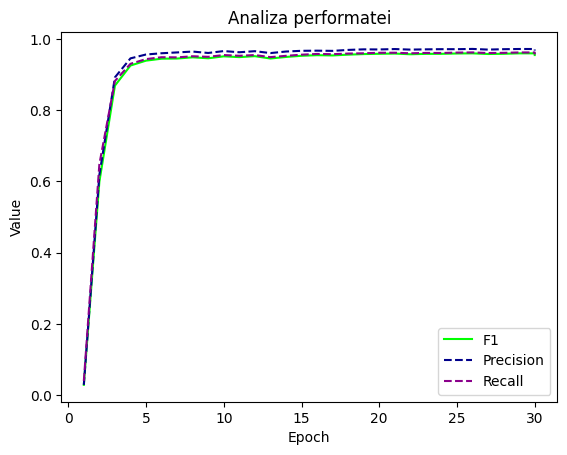

In [10]:
plt.plot(data["epoch"], data["f1"], c = 'lime', label = 'F1')
plt.plot(data["epoch"], data["precision"], c ='darkblue', ls = "--", label = 'Precision')
plt.plot(data["epoch"], data["recall"], c = 'darkmagenta', ls = "--", label = 'Recall')
plt.title('Analiza performatei')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.savefig(os.path.join(os.path.dirname(csv_path), "performance.pdf"))
plt.show()
